# AICL 3605 - Computer Vision Lab
**Author:** Muhammad Haroon  
**Registration Number:** 23108124  
**Lab Session:** LAB 03: Scene enhancement using point processing techniques (Contrast enhancement SPTAIS)


**1. Contrast stretching**

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [4]:
uploaded = files.upload()
img_path= next(iter(uploaded))
img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

Saving gray.jpeg to gray.jpeg


In [5]:
min_val =np.min(img)
max_val =np.max(img)
stretched=((img-min_val)/(max_val-min_val))*255
stretched=stretched.astype(np.uint8)

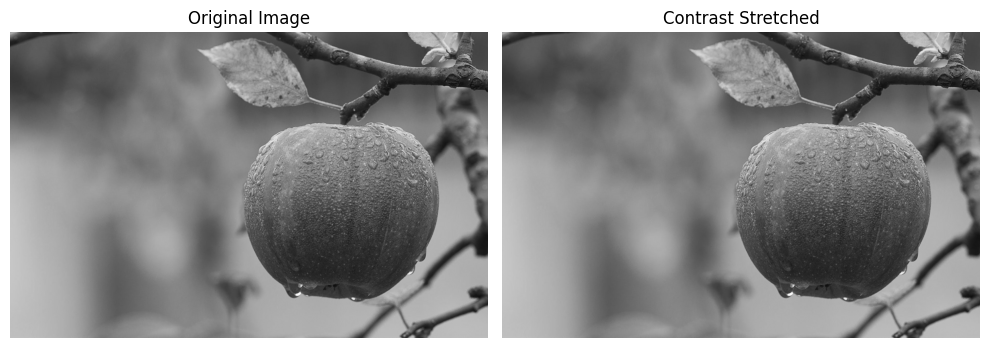

In [17]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Contrast Stretched")
plt.imshow(stretched, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
cv2.imwrite("contrasted_stretched.jpg",stretched)
files.download("contrasted_stretched.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**2. Histogram Equalization**

In [41]:
print("Upload a grayscale image (e.g., .jpg, .png):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Step 2: Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

Upload a grayscale image (e.g., .jpg, .png):


Saving gray.jpeg to gray (4).jpeg


In [42]:
equalized =cv2.equalizeHist(img)

/tmp/ipykernel_331/2904996359.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256])
/tmp/ipykernel_331/2904996359.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0,256])


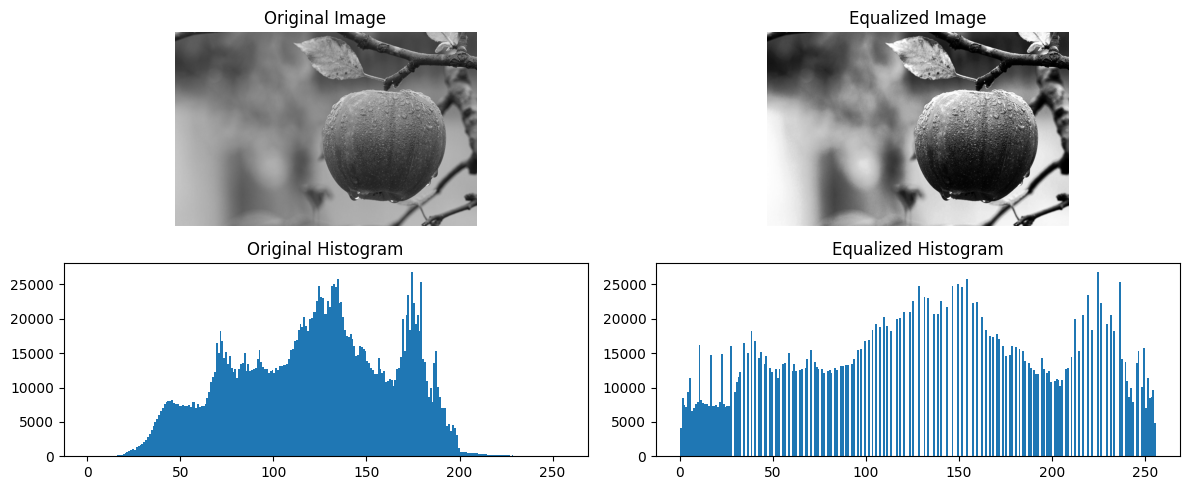

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(img.ravel(), 256, [0,256])
plt.title("Original Histogram")

plt.subplot(2, 2, 4)
plt.hist(equalized.ravel(), 256, [0,256])
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()

**3. Gamma Correction**

In [45]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving gray.jpeg to gray (5).jpeg


In [52]:
img=cv2.imread(image_path)
img_gray =cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [54]:
gamma = 2.2
gamma_corrected = np.array(255* (img_gray/255) **gamma, dtype ='uint8')

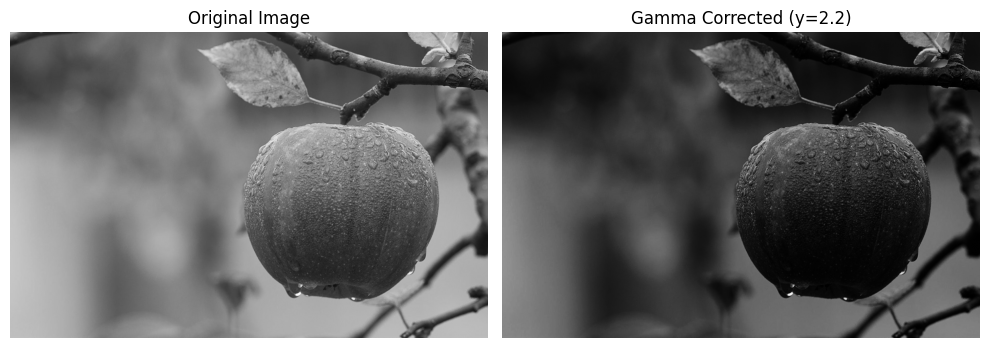

In [55]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gamma_corrected, cmap='gray')
plt.title(f"Gamma Corrected (y={gamma})")
plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study: Medical Imaging**
A radiology department receives low-contrast chest and bone X-rays captured with suboptimal
exposure. These images make it difficult to differentiate between bone, soft tissue, and possible
pathological regions (e.g., fractures or lung lesions).

Objective:

Enhance contrast using histogram equalization to help radiologists spot tissue boundaries and
anomalies more clearly.

In [56]:
uploaded= files.upload()
path = list(uploaded.keys())[0]

Saving images_11_11_6625_01.jpeg to images_11_11_6625_01.jpeg


In [57]:
img =cv2.imread(path,cv2.IMREAD_GRAYSCALE)
equalized = cv2.equalizeHist(img)

/tmp/ipykernel_331/531856813.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(),256,[0,256])


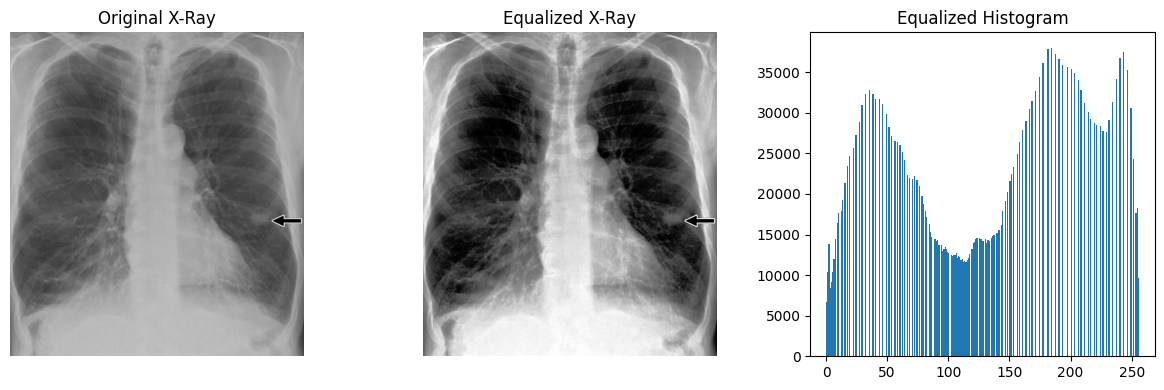

In [58]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray'); plt.title("Original X-Ray"); plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray'); plt.title("Equalized X-Ray"); plt.axis('off')

plt.subplot(1,3,3)
plt.hist(equalized.ravel(),256,[0,256])
plt.title("Equalized Histogram")
plt.tight_layout()
plt.show()

**Case Study: Satellite Image Enhancement**
A remote sensing team is analyzing satellite images taken under hazy or overcast conditions. The
images have poor contrast, obscuring features such as water bodies, vegetation, roads, and farmland
boundaries.

Objective:

Apply gamma correction and histogram equalization to enhance visibility of terrain and land cover
details.

In [59]:
uploaded=files.upload()
path=list(uploaded.keys())[0]

Saving greyscale setalite.jpg to greyscale setalite.jpg


In [61]:
img = cv2.imread(path)
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
equalized=cv2.equalizeHist(gray)
gamma =0.5
gamma_corr= np.array(255 *(gray/255)** gamma,dtype='uint8')

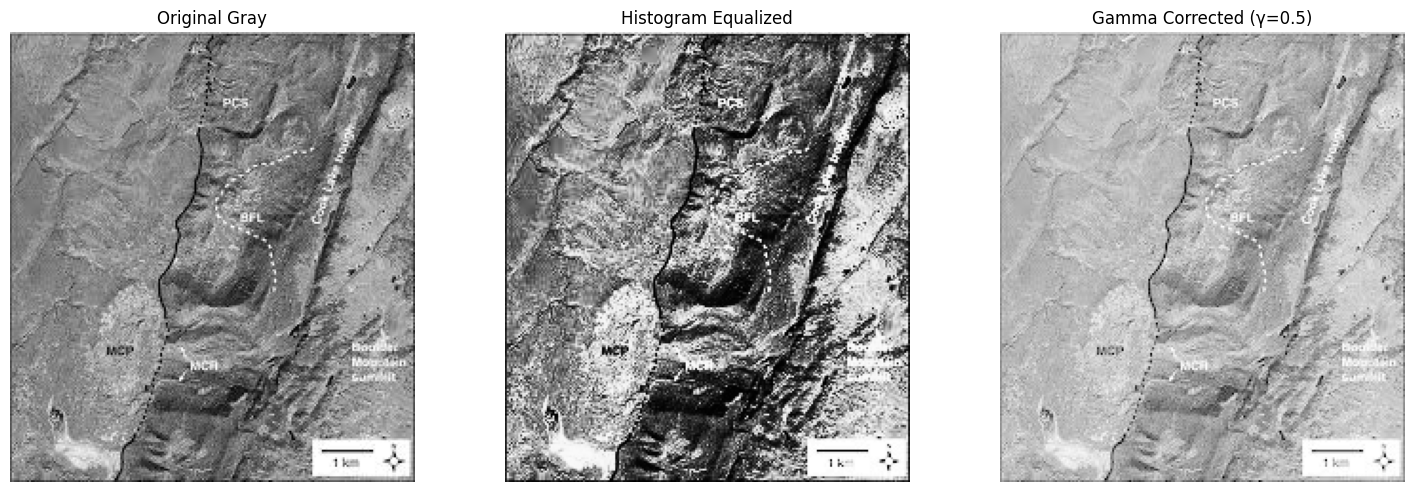

In [62]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray'); plt.title("Original Gray"); plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray'); plt.title("Histogram Equalized"); plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gamma_corr, cmap='gray'); plt.title(f"Gamma Corrected (γ={gamma})"); plt.axis('off')

plt.tight_layout()
plt.show()

**Case Study 3 Surveillance Video Processing**
A security surveillance system captured nighttime video footage where facial details and features are
obscured by low light. These frames make it hard for facial recognition software (and human operators)
to identify subjects.

Objective:

Use histogram equalization to enhance contrast in grayscale video frames, making facial features and
edges more distinct.

In [63]:
uploaded = files.upload()
path =list(uploaded.keys())[0]

img= cv2.imread(path,cv2.IMREAD_GRAYSCALE)
equalized =cv2.equalizeHist(img)


Saving Screenshot 2026-03-08 021439.png to Screenshot 2026-03-08 021439.png


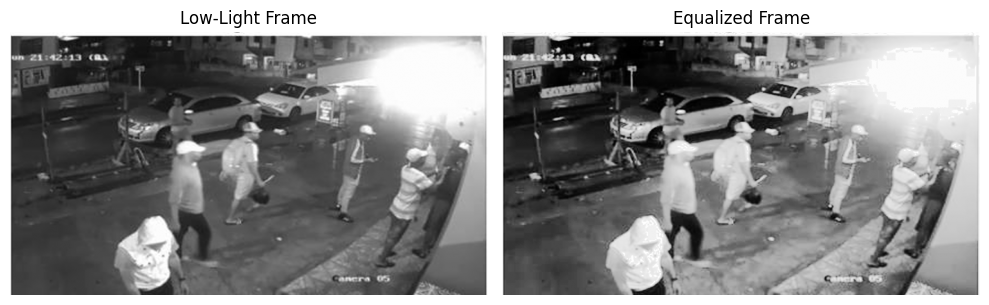

In [64]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray'); plt.title("Low-Light Frame"); plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray'); plt.title("Equalized Frame"); plt.axis('off')

plt.tight_layout()
plt.show()

**Case Study : Document Image Enhancement (OCR Preparation)**
An archival digitization project involves scanning hundreds of old, low-quality paper documents.
These scanned documents have poor contrast, faded ink, and uneven lighting, which reduces the
accuracy of OCR (Optical Character Recognition) systems.

Objective:

Use adaptive histogram equalization (CLAHE) to enhance contrast locally and prepare the images
for better OCR results.

In [65]:
uploaded = files.upload()
path = list(uploaded.keys())[0]


Saving page writting.jpg to page writting.jpg


In [66]:
img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [67]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

In [68]:
enhanced = clahe.apply(gray)

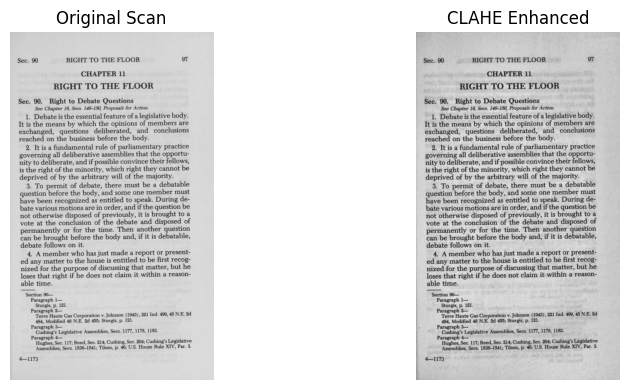

In [69]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray'); plt.title("Original Scan"); plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap='gray'); plt.title("CLAHE Enhanced"); plt.axis('off')
plt.tight_layout()
plt.show()

**Case Study 5: Foggy Road Image Enhancement for Driver Assistance**
An automotive AI system receives input from a dashcam driving in foggy or rainy conditions. Road
signs, lane markings, and pedestrians are barely visible due to low visibility and reduced contrast.

Objective:

Apply contrast stretching (min-max normalization) to improve visibility of objects in foggy images
for better perception and driver assistance.

In [70]:
uploaded = files.upload()
path = list(uploaded.keys())[0]

Saving fog.jpg to fog.jpg


In [71]:
img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [72]:
min_val = np.min(gray)
max_val = np.max(gray)
stretched = ((gray - min_val) / (max_val - min_val) * 255).astype('uint8')

In [73]:
gamma = 0.4
gamma_corrected = np.array(255 * (stretched / 255) ** gamma, dtype='uint8')

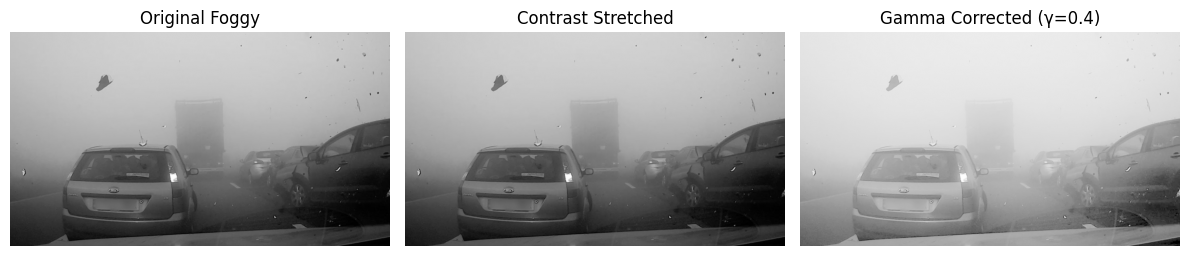

In [74]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray'); plt.title("Original Foggy"); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(stretched, cmap='gray'); plt.title("Contrast Stretched"); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gamma_corrected, cmap='gray'); plt.title(f"Gamma Corrected (γ={gamma})");
plt.axis('off')

plt.tight_layout()
plt.show()